# Digital Payment Trends Analysis in India using UPI Data

This project analyzes UPI transaction data to understand growth trends, transaction volume, and value over time.

# Problem Statement

Analyze UPI transaction data to identify growth patterns, transaction trends, and key insights in digital payment adoption in India.

# Data Loading

In [15]:
#Load UPI monthly payments Dataset
import pandas as pd
df_monthly = pd.read_csv('upi_monthly_payments.csv')
print(df_monthly.shape)
df_monthly.head()

(9, 5)


,Month,Volume (In Mn.),Avg. Daily Volume (In Mn.),Value (In Cr.),Avg. Daily Value (In Cr.)
0,December-2025,2854.73,713.6837,435495.60,108873.9000
1,November-2025,20466.98,682.2326,2631632.64,87721.0880
2,October-2025,20700.92,667.7716,2727790.71,87993.2487
3,September-2025,19633.43,654.4478,2489736.52,82991.2173
4,August-2025,20008.31,645.4294,2485472.90,80176.5452


# Data Cleaning

In [ ]:
dfA = df_monthly.copy()

# Clean column names
dfA.columns = (
    dfA.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace(".", "", regex=False)
)

# Convert month column to datetime
dfA['month'] = pd.to_datetime(dfA['month'], format='%B-%Y')

# Sort values
dfA.sort_values('month', inplace=True)

dfA.head()

month                     0
volume_in_mn              0
avg_daily_volume_in_mn    0
value_in_cr               0
avg_daily_value_in_cr     0
dtype: int64


,month,volume_in_mn,avg_daily_volume_in_mn,value_in_cr,avg_daily_value_in_cr
8,2025-04-01,17893.42,596.4475,2394925.87,79830.8623
7,2025-05-01,18677.45,602.4985,2514297.01,81106.3552
6,2025-06-01,18395.01,613.1669,2403930.69,80131.0230
5,2025-07-01,19467.95,627.9983,2508498.10,80919.2935
4,2025-08-01,20008.31,645.4294,2485472.90,80176.5452


In [21]:
# check missing values
print(dfA.isnull().sum())

month                     0
volume_in_mn              0
avg_daily_volume_in_mn    0
value_in_cr               0
avg_daily_value_in_cr     0
dtype: int64


# Data Type Conversion

In [17]:
#Numeric Conversion
numeric_cols = [
    'volume_in_mn',
    'avg_daily_volume_in_mn',
    'value_in_cr',
    'avg_daily_value_in_cr'
]

for col in numeric_cols:
    dfA[col] = (
        dfA[col]
        .astype(str)
        .str.replace(",", "")
        .str.strip()
    )
    dfA[col] = pd.to_numeric(dfA[col], errors='coerce')

dfA.info()


<class 'pandas.core.frame.DataFrame'>
Index: 9 entries, 8 to 0
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   month                   9 non-null      datetime64[ns]
 1   volume_in_mn            9 non-null      float64       
 2   avg_daily_volume_in_mn  9 non-null      float64       
 3   value_in_cr             9 non-null      float64       
 4   avg_daily_value_in_cr   9 non-null      float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 432.0 bytes


# Basic Metrics

In [22]:
print("Date Range:", dfA['month'].min(), "to", dfA['month'].max())
print(f"Total Transactions (Mn): {dfA['volume_in_mn'].sum():,.2f}")
print(f"Total Value (Cr): {dfA['value_in_cr'].sum():,.2f}")


Date Range: 2025-04-01 00:00:00 to 2025-12-01 00:00:00
Total Transactions (Mn): 158,098.20
Total Value (Cr): 20,591,780.04


# Growth Analysis

In [24]:
dfA['volume_growth_%'] = dfA['volume_in_mn'].pct_change() * 100
dfA['value_growth_%'] = dfA['value_in_cr'].pct_change() * 100

dfA[['month','volume_growth_%','value_growth_%']].head(10)


,month,volume_growth_%,value_growth_%
8,2025-04-01,NaN,NaN
7,2025-05-01,4.381667,4.984335
6,2025-06-01,-1.512198,-4.389550
5,2025-07-01,5.832777,4.349851
4,2025-08-01,2.775639,-0.917888
3,2025-09-01,-1.873622,0.171542
2,2025-10-01,5.437104,9.561421
1,2025-11-01,-1.130095,-3.525126
0,2025-12-01,-86.052021,-83.451505


# Visualization

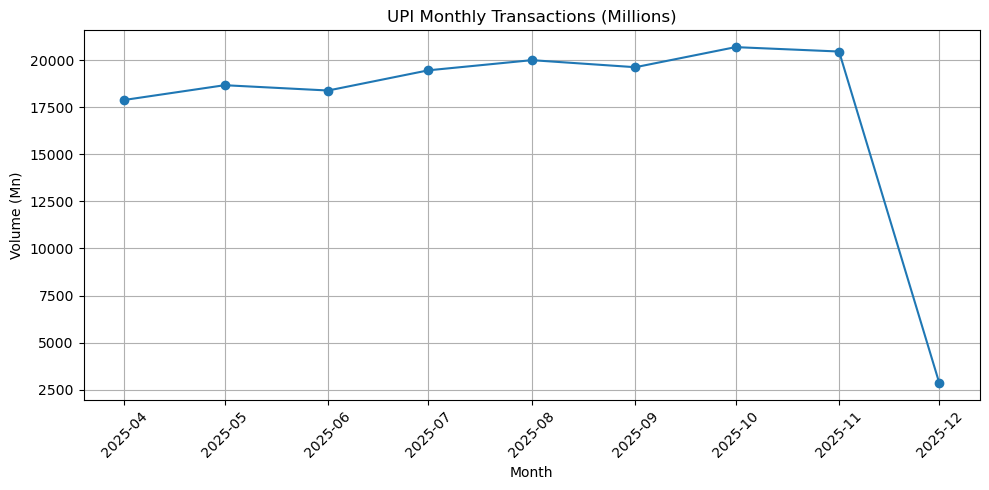

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(dfA['month'], dfA['volume_in_mn'], marker='o')
plt.title("UPI Monthly Transactions (Millions)")
plt.xlabel("Month")
plt.ylabel("Volume (Mn)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


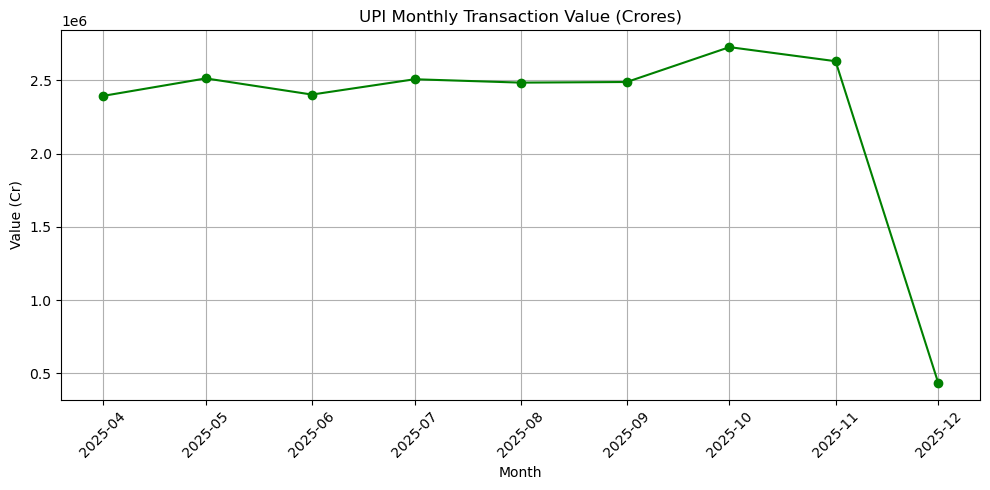

In [19]:
plt.figure(figsize=(10,5))
plt.plot(dfA['month'], dfA['value_in_cr'], marker='o', color='green')
plt.title("UPI Monthly Transaction Value (Crores)")
plt.xlabel("Month")
plt.ylabel("Value (Cr)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Key Insights

- UPI transaction volume has grown exponentially over time
- Transaction value has increased consistently, reflecting higher usage and trust in digital payments.
- Growth percentage reflects rapid expansion of digital payments in India
- UPI has emerged as the dominant digital payment system compared to traditional banking methods.

# Conclusion

The analysis highlights the rapid growth of UPI transactions in India, indicating strong digital payment adoption. The increasing transaction volume and value suggest a shift towards digital financial systems.

Save Clean Data

In [14]:
dfA.to_csv('upi_cleaned.csv', index=False)